# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [ ]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [ ]:
# При необходимости добавляйте новые ячейки для кода или текста

In [1]:
!pip install sqlalchemy

In [3]:
!pip install psycopg2-binary

In [125]:
!pip install phik

     |████████████████████████████████| 677 kB 2.3 MB/s eta 0:00:01


In [126]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import phik
import seaborn as sns

In [5]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [7]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [8]:
engine = create_engine(connection_string)

In [10]:
query = '''
WITH set_config_precode AS (
    SELECT set_config('synchronize_seqscans', 'off', true)
)

SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER (
        PARTITION BY p.user_id
        ORDER BY p.created_dt_msk
    ) AS days_since_prev,
    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
LEFT JOIN afisha.events AS e ON p.event_id = e.event_id
LEFT JOIN afisha.city AS c ON e.city_id = c.city_id
LEFT JOIN afisha.regions AS r ON c.region_id = r.region_id
ORDER BY p.user_id, p.created_dt_msk;
'''

In [15]:
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [16]:
df.shape

(292034, 14)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292034 entries, 0 to 292033
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                292034 non-null  object        
 1   device_type_canonical  292034 non-null  object        
 2   order_id               292034 non-null  int64         
 3   order_dt               292034 non-null  datetime64[ns]
 4   order_ts               292034 non-null  datetime64[ns]
 5   currency_code          292034 non-null  object        
 6   revenue                292034 non-null  float64       
 7   tickets_count          292034 non-null  int64         
 8   days_since_prev        270034 non-null  float64       
 9   event_id               292034 non-null  int64         
 10  service_name           292034 non-null  object        
 11  event_type_main        292034 non-null  object        
 12  region_name            292034 non-null  obje

In [18]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк


In [19]:
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          22000
event_id                     0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
dtype: int64

In [20]:
df.duplicated().sum()

0

In [21]:
df.describe()

,order_id,revenue,tickets_count,days_since_prev,event_id
count,2.920340e+05,292034.000000,292034.000000,270034.000000,292034.000000
mean,4.326435e+06,624.833773,2.754508,3.218550,437938.109908
std,2.498049e+06,1225.695694,1.170305,11.347697,147478.192256
min,1.000000e+00,-90.760000,1.000000,0.000000,4436.000000
25%,2.162567e+06,116.790000,2.000000,0.000000,361300.000000
50%,4.327134e+06,355.340000,3.000000,0.000000,498054.000000
75%,6.489179e+06,809.460000,4.000000,1.000000,546269.000000
max,8.653108e+06,81174.540000,57.000000,148.000000,592325.000000


### Промежуточный вывод

Выгрузка прошла корректно: в датафрейме 290 234 строки и 14 столбцов, все необходимые по техническому заданию поля присутствуют. Этого объёма достаточно, чтобы дальше строить пользовательские профили и анализировать повторные покупки.

Данные в целом готовы к предобработке: даты уже распознаны как дата и время, явные дубликаты отсутствуют. Пропуски есть только в `days_since_prev`, и это ожидаемо: для первого заказа пользователя нет предыдущей покупки, поэтому этот признак не требует заполнения на текущем этапе.

Перед анализом нужно отдельно проверить качество числовых признаков. В `revenue` есть отрицательные значения, а также очень крупные значения по сравнению с основной массой заказов. В `tickets_count` максимум равен 57, что может быть выбросом. Эти наблюдения важны, потому что выручка и количество билетов дальше будут использоваться для оценки лояльности и построения пользовательского профиля.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [22]:
tenge_df = pd.read_csv('/datasets/final_tickets_tenge_df.csv')
tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [23]:
tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [24]:
tenge_df.head(10)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
5,2024-01-15,100,19.4501,kzt
6,2024-01-16,100,19.4264,kzt
7,2024-01-17,100,19.4177,kzt
8,2024-01-18,100,19.5798,kzt
9,2024-01-19,100,19.5741,kzt


In [25]:
tenge_df['data'] = pd.to_datetime(tenge_df['data'])
df['order_date'] = df['order_dt'].dt.normalize()

df = df.merge(
    tenge_df[['data', 'nominal', 'curs']],
    left_on='order_date',
    right_on='data',
    how='left'
)

In [27]:
df['revenue_rub'] = df['revenue']

In [28]:
df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] = (
    df.loc[df['currency_code'] == 'kzt', 'revenue']
    * df.loc[df['currency_code'] == 'kzt', 'curs']
    / df.loc[df['currency_code'] == 'kzt', 'nominal']
)

In [29]:
df[['order_dt', 'currency_code', 'revenue', 'curs', 'nominal', 'revenue_rub']].head(10)

,order_dt,currency_code,revenue,curs,nominal,revenue_rub
0,2024-08-20,rub,1521.94,18.6972,100,1521.94
1,2024-07-23,rub,289.45,18.3419,100,289.45
2,2024-10-06,rub,1258.57,19.6475,100,1258.57
3,2024-07-13,rub,8.49,18.5010,100,8.49
4,2024-10-04,rub,1390.41,19.6648,100,1390.41
5,2024-10-23,rub,902.74,20.0531,100,902.74
6,2024-08-15,rub,917.83,18.7730,100,917.83
7,2024-09-29,rub,47.78,19.3741,100,47.78
8,2024-10-15,rub,74.84,19.7185,100,74.84
9,2024-06-20,rub,1421.91,18.0419,100,1421.91


In [31]:
df['revenue_rub'].isna().sum()

0

In [32]:
df[df['currency_code'] == 'kzt'][['order_dt', 'currency_code', 'revenue', 'curs', 'nominal', 'revenue_rub']].head(10)

,order_dt,currency_code,revenue,curs,nominal,revenue_rub
73,2024-09-17,kzt,518.10,19.0125,100,98.503762
92,2024-09-02,kzt,347.18,18.9330,100,65.731589
99,2024-09-09,kzt,328.77,18.5991,100,61.148261
289,2024-06-11,kzt,22021.55,19.8928,100,4380.702898
472,2024-06-04,kzt,7397.66,19.9833,100,1478.296591
473,2024-06-04,kzt,7397.66,19.9833,100,1478.296591
474,2024-06-04,kzt,3698.83,19.9833,100,739.148295
475,2024-06-04,kzt,7397.66,19.9833,100,1478.296591
476,2024-06-04,kzt,5548.24,19.9833,100,1108.721444
528,2024-09-05,kzt,361.08,18.4217,100,66.517074


### Промежуточный вывод

Выручка была приведена к единой валюте — российскому рублю. Для этого к основной таблице был добавлен курс казахстанского тенге по дате заказа, после чего создан новый столбец `revenue_rub`.

Для заказов в рублях значение выручки осталось без изменений, а для заказов в тенге выручка была пересчитана по курсу за соответствующую дату. Проверка показала, что пропусков в новом столбце `revenue_rub` нет, поэтому этот показатель можно использовать в дальнейшем анализе и при построении пользовательского профиля.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [33]:
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          22000
event_id                     0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
order_date                   0
data                         0
nominal                      0
curs                         0
revenue_rub                  0
dtype: int64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 292034 entries, 0 to 292033
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                292034 non-null  object        
 1   device_type_canonical  292034 non-null  object        
 2   order_id               292034 non-null  int64         
 3   order_dt               292034 non-null  datetime64[ns]
 4   order_ts               292034 non-null  datetime64[ns]
 5   currency_code          292034 non-null  object        
 6   revenue                292034 non-null  float64       
 7   tickets_count          292034 non-null  int64         
 8   days_since_prev        270034 non-null  float64       
 9   event_id               292034 non-null  int64         
 10  service_name           292034 non-null  object        
 11  event_type_main        292034 non-null  object        
 12  region_name            292034 non-null  obje

In [35]:
df.duplicated().sum()

0

In [37]:
for column in ['device_type_canonical', 'currency_code', 'service_name', 
               'event_type_main', 'region_name', 'city_name']:
    print(column)
    print(df[column].value_counts(dropna=False).head(20))
    print()

device_type_canonical
mobile     232679
desktop     58170
tablet       1180
tv              3
other           2
Name: device_type_canonical, dtype: int64

currency_code
rub    286961
kzt      5073
Name: currency_code, dtype: int64

service_name
Билеты без проблем        63932
Лови билет!               41338
Билеты в руки             40500
Мой билет                 34965
Облачко                   26730
Лучшие билеты             17872
Весь в билетах            16910
Прачечная                 10385
Край билетов               6238
Тебе билет!                5242
Яблоко                     5057
Дом культуры               4514
За билетом!                2877
Городской дом культуры     2747
Show_ticket                2208
Мир касс                   2171
Быстробилет                2010
Выступления.ру             1621
Восьмёрка                  1126
Crazy ticket!               796
Name: service_name, dtype: int64

event_type_main
концерты    115634
театр        67744
другое       66109
спорт   

In [38]:
df[['revenue_rub', 'tickets_count', 'days_since_prev']].describe()

,revenue_rub,tickets_count,days_since_prev
count,292034.000000,292034.000000,270034.000000
mean,555.106238,2.754508,3.218550
std,874.381090,1.170305,11.347697
min,-90.760000,1.000000,0.000000
25%,113.480000,2.000000,0.000000
50%,350.330000,3.000000,0.000000
75%,802.050000,4.000000,1.000000
max,81174.540000,57.000000,148.000000


In [42]:
print('Отрицательная выручка:', (df['revenue_rub'] < 0).sum())
print('Нулевая выручка:', (df['revenue_rub'] == 0).sum())

revenue_99 = df['revenue_rub'].quantile(0.99)

print('99-й перцентиль revenue_rub:', revenue_99)
print('Количество строк выше 99-го перцентиля:', (df['revenue_rub'] > revenue_99).sum())
print('Доля строк выше 99-го перцентиля:', (df['revenue_rub'] > revenue_99).mean())

Отрицательная выручка: 381
Нулевая выручка: 5772
99-й перцентиль revenue_rub: 2628.4217390400004
Количество строк выше 99-го перцентиля: 2840
Доля строк выше 99-го перцентиля: 0.009724895046467192


In [43]:
df['tickets_count'].value_counts().sort_index()

1     41963
2     84240
3     92700
4     55100
5     13545
6      4298
7        62
8        21
9        38
10       19
11       13
12        4
13        7
14        4
15        2
17        6
19        5
27        2
30        2
37        1
47        1
57        1
Name: tickets_count, dtype: int64

In [46]:
rows_before = df.shape[0]

df = df[
    (df['revenue_rub'] >= 0) &
    (df['revenue_rub'] <= revenue_99)
].copy()

rows_after = df.shape[0]

print('Строк до фильтрации:', rows_before)
print('Строк после фильтрации:', rows_after)
print('Удалено строк:', rows_before - rows_after)
print('Доля удалённых строк:', (rows_before - rows_after) / rows_before)

Строк до фильтрации: 292034
Строк после фильтрации: 288813
Удалено строк: 3221
Доля удалённых строк: 0.011029537656574235


In [47]:
df[['revenue_rub', 'tickets_count', 'days_since_prev']].describe()

,revenue_rub,tickets_count,days_since_prev
count,288813.000000,288813.000000,267047.000000
mean,518.267670,2.741494,3.221422
std,511.891000,1.162738,11.354811
min,0.000000,1.000000,0.000000
25%,112.160000,2.000000,0.000000
50%,344.270000,3.000000,0.000000
75%,788.660000,3.000000,1.000000
max,2628.421739,57.000000,148.000000


In [48]:
print('Отрицательная выручка:', (df['revenue_rub'] < 0).sum())
print('Выручка выше 99-го перцентиля:', (df['revenue_rub'] > revenue_99).sum())

Отрицательная выручка: 0
Выручка выше 99-го перцентиля: 0


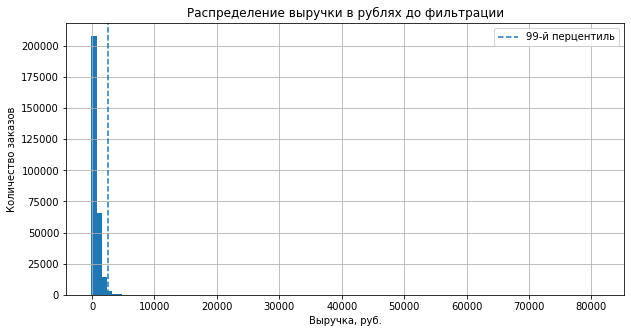

In [45]:
plt.figure(figsize=(10, 5))

df['revenue_rub'].hist(bins=100)

plt.axvline(revenue_99, linestyle='--', label='99-й перцентиль')
plt.title('Распределение выручки в рублях до фильтрации')
plt.xlabel('Выручка, руб.')
plt.ylabel('Количество заказов')
plt.legend()
plt.show()

### Промежуточный вывод

На этапе предобработки были проверены пропуски, типы данных, дубликаты, категориальные значения и ключевые числовые признаки. Пропуски обнаружены только в столбце `days_since_prev`, что соответствует логике данных: для первого заказа пользователя невозможно рассчитать интервал с предыдущей покупки. Явные дубликаты отсутствуют, типы данных соответствуют содержимому столбцов.

В категориальных признаках не обнаружено значений, которые явно обозначают пропуски или требуют дополнительной нормализации на этом этапе. Основная часть заказов приходится на устройства `mobile` и `desktop`, валюты представлены рублями и тенге, а после пересчёта выручки создан единый показатель `revenue_rub`.

При проверке числовых признаков были выявлены некорректные отрицательные значения выручки и аномально высокие значения `revenue_rub`. Так как выручка будет использоваться при построении пользовательского профиля и сравнении сегментов, такие значения могли бы исказить дальнейший анализ. Поэтому были удалены строки с отрицательной выручкой и строки со значениями выше 99-го перцентиля.

После фильтрации осталось 288 813 строк из 290 234. Было удалено 3 221 строка, то есть около 1.1% данных. Такой объём фильтрации небольшой, поэтому он не должен существенно исказить структуру выборки, но позволяет снизить влияние ошибок и выбросов на дальнейший анализ.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [51]:
df = df.sort_values(['user_id', 'order_dt', 'order_ts'])

In [52]:
user_profile = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    first_device_type=('device_type_canonical', 'first'),
    first_region_name=('region_name', 'first'),
    first_service_name=('service_name', 'first'),
    first_event_type_main=('event_type_main', 'first'),
    total_orders=('order_id', 'nunique'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_days_between_orders=('days_since_prev', 'mean')
).reset_index()

In [53]:
user_profile['is_two'] = user_profile['total_orders'] >= 2
user_profile['is_five'] = user_profile['total_orders'] >= 5

In [54]:
user_profile.head()

,user_id,first_order_dt,last_order_dt,first_device_type,first_region_name,first_service_name,first_event_type_main,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False


In [55]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21904 entries, 0 to 21903
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  21904 non-null  object        
 1   first_order_dt           21904 non-null  datetime64[ns]
 2   last_order_dt            21904 non-null  datetime64[ns]
 3   first_device_type        21904 non-null  object        
 4   first_region_name        21904 non-null  object        
 5   first_service_name       21904 non-null  object        
 6   first_event_type_main    21904 non-null  object        
 7   total_orders             21904 non-null  int64         
 8   avg_revenue_rub          21904 non-null  float64       
 9   avg_tickets_count        21904 non-null  float64       
 10  avg_days_between_orders  13559 non-null  float64       
 11  is_two                   21904 non-null  bool          
 12  is_five                  21904 n

In [56]:
user_profile.describe()

,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between_orders
count,21904.000000,21904.000000,21904.000000,13559.000000
mean,13.185400,544.092640,2.743775,15.860739
std,122.035556,431.242731,0.912613,22.342739
min,1.000000,0.000000,1.000000,0.000000
25%,1.000000,212.893868,2.000000,1.000000
50%,2.000000,467.101000,2.750000,8.000000
75%,5.000000,763.616250,3.076923,20.400000
max,10230.000000,2628.421739,11.000000,148.000000


In [57]:
print('Всего пользователей:', user_profile['user_id'].nunique())
print('Пользователей с 2 и более заказами:', user_profile['is_two'].sum())
print('Пользователей с 5 и более заказами:', user_profile['is_five'].sum())

Всего пользователей: 21904
Пользователей с 2 и более заказами: 13528
Пользователей с 5 и более заказами: 6351


### Промежуточный вывод

На основе очищенных данных был создан профиль пользователя. Для каждого пользователя агрегированы признаки, описывающие его первое взаимодействие с сервисом, покупательскую активность и средние характеристики заказов.

В итоговый профиль вошли 21 904 пользователя. Для каждого пользователя определены дата первого и последнего заказа, устройство первого заказа, регион, билетный партнёр и тип первого мероприятия. Также рассчитаны общее количество заказов, средняя выручка с заказа, среднее количество билетов и средний интервал между заказами.

Дополнительно созданы два бинарных признака: `is_two`, который показывает, совершил ли пользователь 2 и более заказа, и `is_five`, который показывает, совершил ли пользователь 5 и более заказов. Эти признаки понадобятся для дальнейшего анализа возврата пользователей и сравнения сегментов.

По предварительной проверке видно, что часть пользователей совершила только один заказ, поэтому для них средний интервал между покупками не рассчитывается. Также в данных есть пользователи с очень большим количеством заказов, что нужно дополнительно изучить на следующем этапе перед интерпретацией результатов.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [58]:
total_users = user_profile['user_id'].nunique()
avg_revenue = user_profile['avg_revenue_rub'].mean()
share_two = user_profile['is_two'].mean()
share_five = user_profile['is_five'].mean()

print('Общее число пользователей:', total_users)
print('Средняя выручка с одного заказа:', avg_revenue)
print('Доля пользователей с 2 и более заказами:', share_two)
print('Доля пользователей с 5 и более заказами:', share_five)

Общее число пользователей: 21904
Средняя выручка с одного заказа: 544.0926404860893
Доля пользователей с 2 и более заказами: 0.6176040905770636
Доля пользователей с 5 и более заказами: 0.2899470416362308


In [59]:
user_profile[['total_orders', 'avg_tickets_count', 'avg_days_between_orders']].describe()

,total_orders,avg_tickets_count,avg_days_between_orders
count,21904.000000,21904.000000,13559.000000
mean,13.185400,2.743775,15.860739
std,122.035556,0.912613,22.342739
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.000000
75%,5.000000,3.076923,20.400000
max,10230.000000,11.000000,148.000000


In [60]:
user_profile['total_orders'].quantile([0.9, 0.95, 0.99])

0.90     15.0
0.95     31.0
0.99    152.0
Name: total_orders, dtype: float64

In [61]:
user_profile.sort_values('total_orders', ascending=False).head(10)

,user_id,first_order_dt,last_order_dt,first_device_type,first_region_name,first_service_name,first_event_type_main,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between_orders,is_two,is_five
984,0beb8fc0c0a9ce1,2024-06-01,2024-10-31,mobile,Североярская область,Билеты в руки,концерты,10230,504.885778,2.863734,0.014762,True,True
2060,18e9aead0a393e7,2024-06-01,2024-10-31,mobile,Каменевский регион,Облачко,концерты,4356,495.882374,2.790174,0.034214,True,True
11100,8187dac4be757a0,2024-06-01,2024-10-31,mobile,Берёзовская область,Билеты в руки,концерты,4060,535.175249,2.745074,0.036955,True,True
5424,3ee7dc2e115847f,2024-06-01,2024-10-31,mobile,Каменевский регион,Мой билет,концерты,3799,537.281759,2.764938,0.039494,True,True
10837,7eb4fc207ecc10f,2024-06-01,2024-10-31,mobile,Каменевский регион,Билеты без проблем,театр,3725,542.256175,2.955705,0.040548,True,True
2336,1c2a2133e1df1b4,2024-06-01,2024-10-31,mobile,Североярская область,Реестр,концерты,3517,541.473279,2.669605,0.043231,True,True
6790,4ec8f6429431987,2024-06-01,2024-10-31,mobile,Североярская область,Реестр,концерты,3382,549.658403,2.726493,0.044366,True,True
14800,ad2dc32364ed948,2024-06-01,2024-10-31,mobile,Яблоневская область,Лови билет!,театр,3271,447.112493,2.938551,0.045566,True,True
15538,b54dd0cd81121fc,2024-06-01,2024-10-31,mobile,Берёзовская область,Лови билет!,другое,3148,484.997380,2.819568,0.047664,True,True
17674,cdbc02c6ad8087a,2024-06-01,2024-10-31,mobile,Чистогорская область,Лови билет!,спорт,3045,467.832057,2.765189,0.049606,True,True


In [62]:
user_profile['avg_tickets_count'].quantile([0.9, 0.95, 0.99])

0.90    4.0
0.95    4.0
0.99    5.0
Name: avg_tickets_count, dtype: float64

In [63]:
users_before = user_profile.shape[0]
users_before

21904

In [64]:
orders_99 = user_profile['total_orders'].quantile(0.99)
orders_99

152.0

In [65]:
user_profile_filtered = user_profile[
    user_profile['total_orders'] <= orders_99
].copy()

In [66]:
users_after = user_profile_filtered.shape[0]

print('Пользователей до фильтрации:', users_before)
print('Пользователей после фильтрации:', users_after)
print('Удалено пользователей:', users_before - users_after)
print('Доля удалённых пользователей:', (users_before - users_after) / users_before)

Пользователей до фильтрации: 21904
Пользователей после фильтрации: 21685
Удалено пользователей: 219
Доля удалённых пользователей: 0.009998173849525201


In [67]:
total_users_filtered = user_profile_filtered['user_id'].nunique()
avg_revenue_filtered = user_profile_filtered['avg_revenue_rub'].mean()
share_two_filtered = user_profile_filtered['is_two'].mean()
share_five_filtered = user_profile_filtered['is_five'].mean()

print('Общее число пользователей:', total_users_filtered)
print('Средняя выручка с одного заказа:', avg_revenue_filtered)
print('Доля пользователей с 2 и более заказами:', share_two_filtered)
print('Доля пользователей с 5 и более заказами:', share_five_filtered)

Общее число пользователей: 21685
Средняя выручка с одного заказа: 544.3978361655104
Доля пользователей с 2 и более заказами: 0.6137422181231266
Доля пользователей с 5 и более заказами: 0.28277611252017526


In [68]:
user_profile_filtered[['total_orders', 'avg_tickets_count', 'avg_days_between_orders']].describe()

,total_orders,avg_tickets_count,avg_days_between_orders
count,21685.000000,21685.000000,13340.000000
mean,6.488633,2.743956,16.113486
std,14.258747,0.917069,22.437406
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.333333
50%,2.000000,2.750000,8.375000
75%,5.000000,3.100000,20.762500
max,152.000000,11.000000,148.000000


### Промежуточный вывод

В профиле пользователей представлено 21 904 пользователя. До фильтрации доля пользователей с 2 и более заказами составляла около 61.8%, а доля пользователей с 5 и более заказами — около 29.0%. Средняя выручка с одного заказа составляла около 544 руб.

При проверке статистических показателей была обнаружена аномалия в количестве заказов. Медианное значение `total_orders` равно 2, 75% пользователей совершили не более 5 заказов, а 99-й перцентиль составляет 152 заказа. При этом максимальное значение достигало 10 230 заказов, что сильно отличается от основной массы пользователей. Такие значения могут искажать средние показатели и дальнейший корреляционный анализ, поэтому пользователи с количеством заказов выше 99-го перцентиля были исключены.

После фильтрации осталось 21 685 пользователей, было удалено 219 пользователей, то есть около 1% выборки. Это небольшая доля данных, поэтому фильтрация снижает влияние аномалий, но не должна существенно исказить структуру выборки.

В обновлённом профиле доля пользователей с 2 и более заказами составляет около 61.4%, доля пользователей с 5 и более заказами — около 28.3%, а средняя выручка с одного заказа остаётся около 544 руб. Значит, удаление аномальных пользователей почти не изменило ключевые показатели, но сделало данные более устойчивыми для дальнейшего анализа.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [70]:
user_profile = user_profile_filtered.copy()

In [71]:
def segment_distribution(data, column):
    result = (
        data.groupby(column)
        .agg(users=('user_id', 'nunique'))
        .reset_index()
        .sort_values('users', ascending=False)
    )
    
    result['share'] = result['users'] / result['users'].sum()
    
    return result

In [72]:
event_type_dist = segment_distribution(user_profile, 'first_event_type_main')
event_type_dist

,first_event_type_main,users,share
2,концерты,9576,0.441596
1,другое,5407,0.249343
5,театр,4265,0.196680
4,стендап,1107,0.051049
3,спорт,797,0.036754
0,выставки,413,0.019045
7,ёлки,93,0.004289
6,фильм,27,0.001245


In [73]:
device_dist = segment_distribution(user_profile, 'first_device_type')
device_dist

,first_device_type,users,share
1,mobile,17881,0.824579
0,desktop,3706,0.170902
2,tablet,98,0.004519


In [74]:
region_dist = segment_distribution(user_profile, 'first_region_name')
region_dist.head(10)

,first_region_name,users,share
23,Каменевский регион,7105,0.327646
60,Североярская область,3782,0.174406
77,Широковская область,1224,0.056445
45,Озернинский край,677,0.031220
41,Малиновоярский округ,526,0.024256
76,Шанырский регион,502,0.023150
74,Травяная область,493,0.022735
57,Светополянский округ,459,0.021167
52,Речиновская область,443,0.020429
78,Яблоневская область,411,0.018953


In [75]:
service_dist = segment_distribution(user_profile, 'first_service_name')
service_dist.head(10)

,first_service_name,users,share
3,Билеты без проблем,5189,0.239290
22,Мой билет,2975,0.137192
19,Лови билет!,2821,0.130090
4,Билеты в руки,2563,0.118192
23,Облачко,2179,0.100484
7,Весь в билетах,1286,0.059304
20,Лучшие билеты,1197,0.055199
24,Прачечная,581,0.026793
17,Край билетов,455,0.020982
12,Дом культуры,355,0.016371


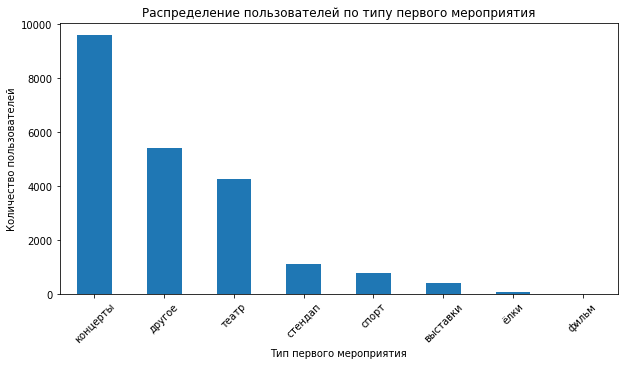

In [76]:
event_type_dist.plot(
    x='first_event_type_main',
    y='users',
    kind='bar',
    figsize=(10, 5),
    legend=False
)

plt.title('Распределение пользователей по типу первого мероприятия')
plt.xlabel('Тип первого мероприятия')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.show()

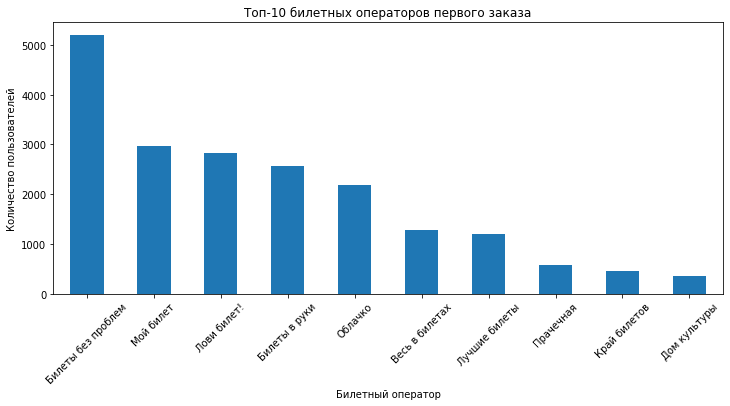

In [77]:
service_dist.head(10).plot(
    x='first_service_name',
    y='users',
    kind='bar',
    figsize=(12, 5),
    legend=False
)

plt.title('Топ-10 билетных операторов первого заказа')
plt.xlabel('Билетный оператор')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.show()

### Промежуточный вывод

Распределение пользователей по признакам первого заказа оказалось неравномерным. Самой заметной точкой входа являются концерты: с них начали взаимодействие с сервисом около 44% пользователей. Также значимыми первыми категориями стали мероприятия типа `другое` и театр. Остальные типы мероприятий привлекают заметно меньшую долю новых пользователей.

По устройствам заметно доминируют мобильные покупки: около 82% пользователей совершили первый заказ с мобильного устройства. Это говорит о том, что мобильный канал является основным для первого контакта пользователя с сервисом.

По регионам также есть выраженная концентрация. Больше всего первых заказов приходится на Каменевский регион и Северорскую область. Это означает, что пользовательская база распределена территориально неравномерно, и дальнейший анализ возврата стоит проводить с учётом размера региональных сегментов.

Среди билетных операторов первые заказы чаще всего проходят через `Билеты без проблем`, `Мой билет`, `Лови билет!`, `Билеты в руки` и `Облачко`. Эти операторы можно рассматривать как важные точки входа пользователей на платформу.

Таким образом, пользователи распределены по сегментам неравномерно: наиболее выраженные точки входа — концерты, мобильные устройства, Каменевский регион и несколько крупнейших билетных операторов.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [79]:
user_profile['is_two'].mean()

0.6137422181231266

In [80]:
def segment_return_rate(data, column):
    result = (
        data.groupby(column)
        .agg(
            users=('user_id', 'nunique'),
            returned_users=('is_two', 'sum'),
            return_rate=('is_two', 'mean')
        )
        .reset_index()
        .sort_values('return_rate', ascending=False)
    )
    
    return result

In [81]:
event_type_return = segment_return_rate(user_profile, 'first_event_type_main')
event_type_return

,first_event_type_main,users,returned_users,return_rate
6,фильм,27,22,0.814815
0,выставки,413,265,0.641646
5,театр,4265,2709,0.635170
2,концерты,9576,5925,0.618734
4,стендап,1107,677,0.611563
1,другое,5407,3214,0.594415
7,ёлки,93,52,0.559140
3,спорт,797,445,0.558344


In [82]:
device_return = segment_return_rate(user_profile, 'first_device_type')
device_return

,first_device_type,users,returned_users,return_rate
0,desktop,3706,2368,0.638964
1,mobile,17881,10888,0.608914
2,tablet,98,53,0.540816


In [83]:
region_return = segment_return_rate(user_profile, 'first_region_name')

top_regions = (
    region_return
    .sort_values('users', ascending=False)
    .head(10)
    .sort_values('return_rate', ascending=False)
)

top_regions

,first_region_name,users,returned_users,return_rate
76,Шанырский регион,502,338,0.673307
57,Светополянский округ,459,302,0.657952
77,Широковская область,1224,790,0.645425
60,Североярская область,3782,2416,0.638815
52,Речиновская область,443,277,0.625282
23,Каменевский регион,7105,4441,0.625053
74,Травяная область,493,303,0.614604
78,Яблоневская область,411,244,0.593674
41,Малиновоярский округ,526,296,0.562738
45,Озернинский край,677,372,0.549483


In [84]:
service_return = segment_return_rate(user_profile, 'first_service_name')

top_services = (
    service_return
    .sort_values('users', ascending=False)
    .head(10)
    .sort_values('return_rate', ascending=False)
)

top_services

,first_service_name,users,returned_users,return_rate
17,Край билетов,455,297,0.652747
12,Дом культуры,355,230,0.647887
24,Прачечная,581,366,0.629948
7,Весь в билетах,1286,807,0.627527
4,Билеты в руки,2563,1608,0.627390
23,Облачко,2179,1338,0.614043
20,Лучшие билеты,1197,734,0.613200
22,Мой билет,2975,1815,0.610084
19,Лови билет!,2821,1721,0.610067
3,Билеты без проблем,5189,3134,0.603970


In [85]:
overall_return_rate = user_profile['is_two'].mean()
overall_return_rate

0.6137422181231266

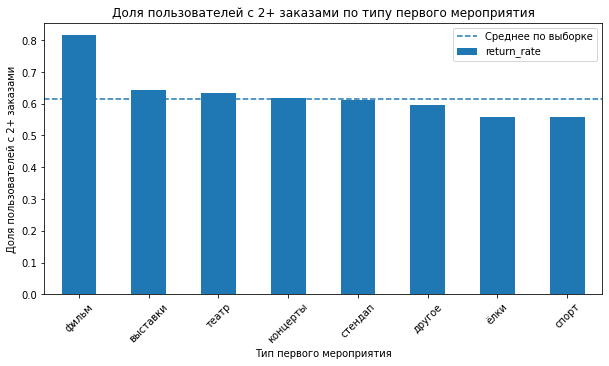

In [86]:
event_type_return.plot(
    x='first_event_type_main',
    y='return_rate',
    kind='bar',
    figsize=(10, 5),
    legend=False
)

plt.axhline(overall_return_rate, linestyle='--', label='Среднее по выборке')
plt.title('Доля пользователей с 2+ заказами по типу первого мероприятия')
plt.xlabel('Тип первого мероприятия')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.xticks(rotation=45)
plt.legend()
plt.show()

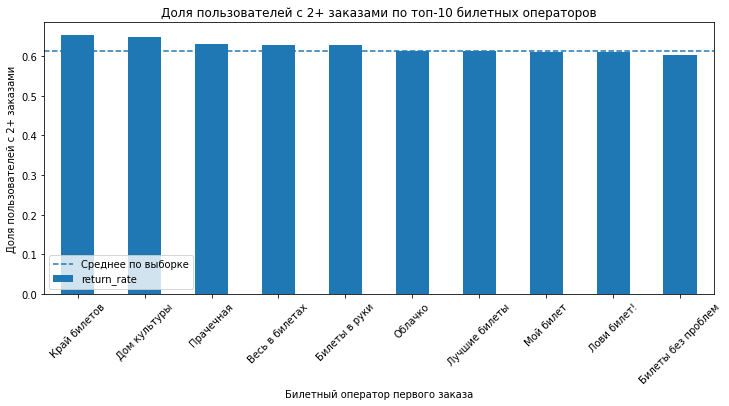

In [87]:
top_services.plot(
    x='first_service_name',
    y='return_rate',
    kind='bar',
    figsize=(12, 5),
    legend=False
)

plt.axhline(overall_return_rate, linestyle='--', label='Среднее по выборке')
plt.title('Доля пользователей с 2+ заказами по топ-10 билетных операторов')
plt.xlabel('Билетный оператор первого заказа')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.xticks(rotation=45)
plt.legend()
plt.show()

### Промежуточный вывод

Средняя доля пользователей, совершивших 2 и более заказа, составляет около 61.4%. Это значение использовалось как ориентир для сравнения сегментов.

По типу первого мероприятия выше среднего возвращаются пользователи, которые начали с выставок, театра и концертов. Сегмент `фильм` показывает самую высокую долю возврата — около 81.5%, однако в нём всего 27 пользователей, поэтому этот результат нельзя считать устойчивым. Среди крупных сегментов наиболее сильными точками входа выглядят выставки, театр и концерты.

По устройству первой покупки лучшие показатели у пользователей, начавших с desktop: доля возврата составляет около 63.9%. У mobile доля немного ниже среднего — около 60.9%, но именно mobile остаётся основным каналом привлечения по количеству пользователей. Сегмент tablet небольшой и показывает более низкую долю возврата, поэтому его не стоит считать приоритетным без дополнительной проверки.

Среди крупнейших региональных сегментов выше среднего возвращаются пользователи из Шанырского региона, Светополянского округа, Широковской области, Северорской области, Речиновской области, Каменевского региона и Травяной области. Эти регионы можно рассматривать как более успешные по удержанию, но приоритет стоит отдавать тем, где одновременно высокая доля возврата и достаточный размер сегмента.

Среди топ-10 билетных операторов выше среднего доля возврата у `Край билетов`, `Дом культуры`, `Прачечная`, `Весь в билетах`, `Билеты в руки`, `Облачко` и `Лучшие билеты`. Эти операторы выглядят более успешными точками входа, так как пользователи после первого заказа через них чаще возвращаются за повторными покупками.

В целом возврат пользователей заметно зависит от сегмента первого заказа. Наиболее перспективные точки входа — крупные сегменты с долей возврата выше среднего: выставки, театр, концерты, desktop, а также отдельные регионы и билетные операторы из верхней части рейтинга.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [93]:
event_type_return[
    event_type_return['first_event_type_main'].isin(['спорт', 'концерты'])
]

,first_event_type_main,users,returned_users,return_rate
2,концерты,9576,5925,0.618734
3,спорт,797,445,0.558344


In [94]:
sport_return = event_type_return.loc[
    event_type_return['first_event_type_main'] == 'спорт', 
    'return_rate'
].iloc[0]

concert_return = event_type_return.loc[
    event_type_return['first_event_type_main'] == 'концерты', 
    'return_rate'
].iloc[0]

print('Доля возврата после первого заказа на спорт:', sport_return)
print('Доля возврата после первого заказа на концерты:', concert_return)
print('Разница:', sport_return - concert_return)

Доля возврата после первого заказа на спорт: 0.5583437892095358
Доля возврата после первого заказа на концерты: 0.618734335839599
Разница: -0.06039054663006327


In [95]:
top_10_region_names = (
    region_return
    .sort_values('users', ascending=False)
    .head(10)['first_region_name']
)

In [96]:
user_profile['region_activity_group'] = 'остальные регионы'

user_profile.loc[
    user_profile['first_region_name'].isin(top_10_region_names),
    'region_activity_group'
] = 'топ-10 регионов по числу пользователей'

In [97]:
region_activity_comparison = (
    user_profile
    .groupby('region_activity_group')
    .agg(
        users=('user_id', 'nunique'),
        returned_users=('is_two', 'sum'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

region_activity_comparison

,region_activity_group,users,returned_users,return_rate
0,остальные регионы,6063,3530,0.582220
1,топ-10 регионов по числу пользователей,15622,9779,0.625976


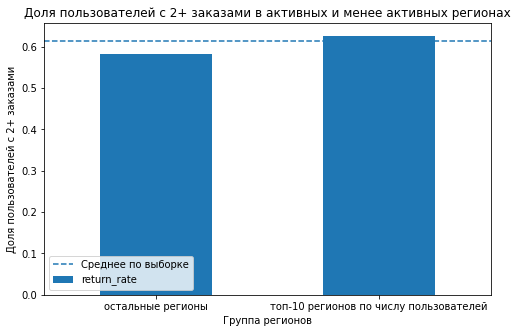

In [98]:
region_activity_comparison.plot(
    x='region_activity_group',
    y='return_rate',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.axhline(overall_return_rate, linestyle='--', label='Среднее по выборке')
plt.title('Доля пользователей с 2+ заказами в активных и менее активных регионах')
plt.xlabel('Группа регионов')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.xticks(rotation=0)
plt.legend()
plt.show()

### Промежуточный вывод

Были проверены две продуктовые гипотезы о связи признаков первого заказа с возвратом пользователей.

Первая гипотеза не подтвердилась. Пользователи, которые совершили первый заказ на спортивные мероприятия, возвращаются реже, чем пользователи, начавшие с концертов. Доля возврата в спортивном сегменте составляет около 55.8%, а в сегменте концертов — около 61.9%. Следовательно, спорт не выглядит более сильной точкой входа по сравнению с концертами.

Вторая гипотеза подтвердилась. В топ-10 регионах по числу пользователей доля повторных заказов составляет около 62.6%, тогда как в остальных регионах — около 58.2%. Это означает, что в более активных регионах пользователи чаще возвращаются на платформу.

С практической точки зрения концерты и активные регионы выглядят более перспективными для удержания пользователей. Спортивные мероприятия, наоборот, требуют дополнительного изучения: несмотря на наличие аудитории, пользователи после первого спортивного события возвращаются реже среднего.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [99]:
user_profile['orders_group'] = '1 заказ'

user_profile.loc[
    user_profile['total_orders'] >= 2,
    'orders_group'
] = '2 и более заказа'

In [100]:
user_profile['orders_group'].value_counts()

2 и более заказа    13309
1 заказ              8376
Name: orders_group, dtype: int64

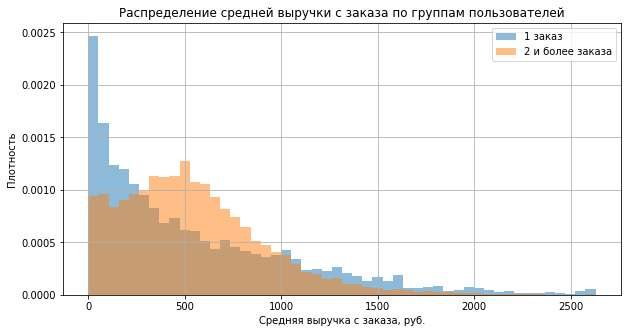

In [101]:
plt.figure(figsize=(10, 5))

user_profile.loc[
    user_profile['orders_group'] == '1 заказ',
    'avg_revenue_rub'
].hist(
    bins=50,
    alpha=0.5,
    density=True,
    label='1 заказ'
)

user_profile.loc[
    user_profile['orders_group'] == '2 и более заказа',
    'avg_revenue_rub'
].hist(
    bins=50,
    alpha=0.5,
    density=True,
    label='2 и более заказа'
)

plt.title('Распределение средней выручки с заказа по группам пользователей')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.legend()
plt.show()

In [102]:
user_profile.groupby('orders_group')['avg_revenue_rub'].describe()

,count,mean,std,min,25%,50%,75%,max
orders_group,,,,,,,,
1 заказ,8376.0,544.349443,519.065337,0.0,131.5700,376.7950,827.490,2628.421739
2 и более заказа,13309.0,544.428292,369.231060,0.0,271.5415,495.5525,745.068,2628.421739


### Промежуточный вывод

Пользователи были разделены на две группы: совершившие один заказ и совершившие 2 и более заказа. В группе с одним заказом 8 376 пользователей, в группе с повторными заказами — 13 309 пользователей.

Средняя выручка с заказа в двух группах почти не отличается и составляет около 544 руб. Однако распределения показывают различия. У пользователей с одним заказом больше концентрация в зоне низкой средней выручки, тогда как у пользователей с 2 и более заказами распределение смещено правее.

Медианная средняя выручка у повторных пользователей выше: около 496 руб. против 377 руб. у пользователей с одним заказом. Это означает, что среди пользователей, которые возвращаются, чаще встречаются клиенты со средней выручкой на заказ выше типичного значения для группы с одним заказом.

Следовательно, сама средняя выручка по группам почти одинакова из-за влияния разброса и верхних значений, но по распределению видно, что повторные пользователи чаще концентрируются в более высоком диапазоне средней выручки.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [103]:
revenue_group_profile = user_profile[
    user_profile['total_orders'] >= 2
].copy()

revenue_group_profile['orders_group_2'] = '2–4 заказа'

revenue_group_profile.loc[
    revenue_group_profile['total_orders'] >= 5,
    'orders_group_2'
] = '5 и более заказов'

In [104]:
revenue_group_profile['orders_group_2'].value_counts()

2–4 заказа           7177
5 и более заказов    6132
Name: orders_group_2, dtype: int64

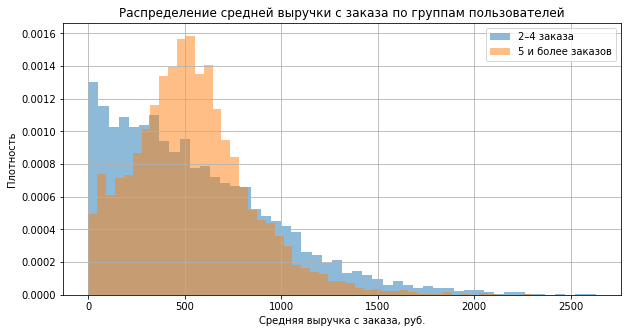

In [105]:
plt.figure(figsize=(10, 5))

revenue_group_profile.loc[
    revenue_group_profile['orders_group_2'] == '2–4 заказа',
    'avg_revenue_rub'
].hist(
    bins=50,
    alpha=0.5,
    density=True,
    label='2–4 заказа'
)

revenue_group_profile.loc[
    revenue_group_profile['orders_group_2'] == '5 и более заказов',
    'avg_revenue_rub'
].hist(
    bins=50,
    alpha=0.5,
    density=True,
    label='5 и более заказов'
)

plt.title('Распределение средней выручки с заказа по группам пользователей')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.legend()
plt.show()

In [106]:
revenue_group_profile.groupby('orders_group_2')['avg_revenue_rub'].describe()

,count,mean,std,min,25%,50%,75%,max
orders_group_2,,,,,,,,
2–4 заказа,7177.0,551.676208,420.040847,0.0,218.940000,470.823333,798.692500,2628.421739
5 и более заказов,6132.0,535.945205,298.801410,0.0,330.832395,512.705306,700.717453,2299.869022


### Промежуточный вывод

Для сравнения были выделены две группы пользователей: совершившие 2–4 заказа и совершившие 5 и более заказов. В группе 2–4 заказа — 7 177 пользователей, в группе 5 и более заказов — 6 132 пользователя. Обе группы достаточно крупные, поэтому сравнение можно считать устойчивым.

По среднему значению выручка с заказа немного выше у пользователей с 2–4 заказами: около 552 руб. против 536 руб. у пользователей с 5 и более заказами. Однако медианное значение выше у более лояльной группы: около 513 руб. против 471 руб. Это означает, что типичный пользователь с 5 и более заказами приносит немного больше выручки за заказ.

Гистограмма показывает, что у пользователей с 5 и более заказами распределение сильнее сконцентрировано в среднем диапазоне, примерно около 400–700 руб. У пользователей с 2–4 заказами больше значений в зоне низкой средней выручки и заметнее правый хвост, поэтому среднее значение в этой группе сильнее зависит от крупных заказов.

Существенного разрыва между группами нет, но пользователи с 5 и более заказами выглядят более стабильным и качественным сегментом: у них выше медианная средняя выручка и меньше разброс значений.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [107]:
user_profile['avg_tickets_count'].describe()

count    21685.000000
mean         2.743956
std          0.917069
min          1.000000
25%          2.000000
50%          2.750000
75%          3.100000
max         11.000000
Name: avg_tickets_count, dtype: float64

In [108]:
user_profile['tickets_group'] = 'от 1 до 2 билетов'

user_profile.loc[
    user_profile['avg_tickets_count'] >= 2,
    'tickets_group'
] = 'от 2 до 3 билетов'

user_profile.loc[
    user_profile['avg_tickets_count'] >= 3,
    'tickets_group'
] = 'от 3 до 5 билетов'

user_profile.loc[
    user_profile['avg_tickets_count'] >= 5,
    'tickets_group'
] = 'от 5 и более билетов'

In [109]:
tickets_return = (
    user_profile
    .groupby('tickets_group')
    .agg(
        users=('user_id', 'nunique'),
        returned_users=('is_two', 'sum'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

tickets_return

,tickets_group,users,returned_users,return_rate
0,от 1 до 2 билетов,2422,1242,0.512799
1,от 2 до 3 билетов,9508,7000,0.736222
2,от 3 до 5 билетов,9094,4942,0.543435
3,от 5 и более билетов,661,125,0.189107


In [110]:
tickets_order = [
    'от 1 до 2 билетов',
    'от 2 до 3 билетов',
    'от 3 до 5 билетов',
    'от 5 и более билетов'
]

tickets_return['tickets_group'] = pd.Categorical(
    tickets_return['tickets_group'],
    categories=tickets_order,
    ordered=True
)

tickets_return = tickets_return.sort_values('tickets_group')
tickets_return

,tickets_group,users,returned_users,return_rate
0,от 1 до 2 билетов,2422,1242,0.512799
1,от 2 до 3 билетов,9508,7000,0.736222
2,от 3 до 5 билетов,9094,4942,0.543435
3,от 5 и более билетов,661,125,0.189107


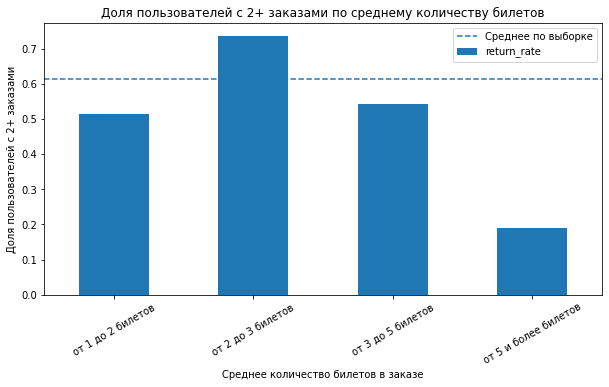

In [111]:
tickets_return.plot(
    x='tickets_group',
    y='return_rate',
    kind='bar',
    figsize=(10, 5),
    legend=False
)

plt.axhline(overall_return_rate, linestyle='--', label='Среднее по выборке')
plt.title('Доля пользователей с 2+ заказами по среднему количеству билетов')
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.xticks(rotation=30)
plt.legend()
plt.show()

### Промежуточный вывод

Пользователи были разделены на четыре сегмента по среднему количеству билетов в заказе. Распределение оказалось неравномерным: основная часть пользователей сосредоточена в сегментах `от 2 до 3 билетов` и `от 3 до 5 билетов`. Значительно меньше пользователей покупают в среднем от 1 до 2 билетов или 5 и более билетов.

Самая высокая доля повторных покупок наблюдается в сегменте `от 2 до 3 билетов` — около 73.6%. Это заметно выше среднего уровня по выборке. Пользователи со средним количеством билетов от 3 до 5 возвращаются реже — около 54.3%, а пользователи с 1–2 билетами имеют долю возврата около 51.3%.

Самый низкий показатель у сегмента `от 5 и более билетов` — около 18.9%. При этом сегмент небольшой, всего 661 пользователь, но снижение достаточно сильное, поэтому его стоит интерпретировать как потенциально проблемный: крупные по количеству билетов заказы не связаны с более высокой вероятностью повторной покупки.

В целом повторные покупки чаще совершают пользователи со средним количеством билетов от 2 до 3. Сегменты с меньшим и особенно с очень большим средним количеством билетов показывают более низкую долю возврата.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [112]:
user_profile['first_order_weekday'] = user_profile['first_order_dt'].dt.day_name()

In [113]:
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

weekday_return = (
    user_profile
    .groupby('first_order_weekday')
    .agg(
        users=('user_id', 'nunique'),
        returned_users=('is_two', 'sum'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

weekday_return['first_order_weekday'] = pd.Categorical(
    weekday_return['first_order_weekday'],
    categories=weekday_order,
    ordered=True
)

weekday_return = weekday_return.sort_values('first_order_weekday')
weekday_return

,first_order_weekday,users,returned_users,return_rate
1,Monday,2928,1845,0.630123
5,Tuesday,3185,1975,0.620094
6,Wednesday,3074,1917,0.623617
4,Thursday,3116,1852,0.594352
0,Friday,3258,1952,0.599141
2,Saturday,3332,2095,0.628752
3,Sunday,2792,1673,0.599212


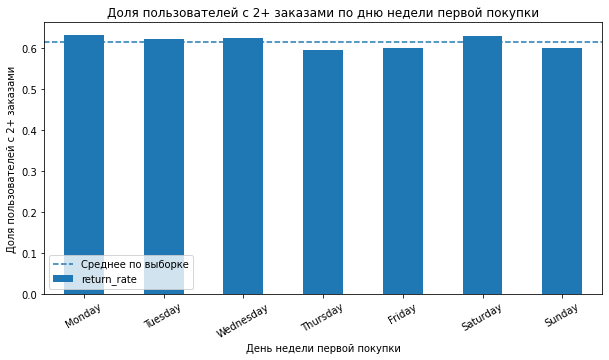

In [114]:
weekday_return.plot(
    x='first_order_weekday',
    y='return_rate',
    kind='bar',
    figsize=(10, 5),
    legend=False
)

plt.axhline(overall_return_rate, linestyle='--', label='Среднее по выборке')
plt.title('Доля пользователей с 2+ заказами по дню недели первой покупки')
plt.xlabel('День недели первой покупки')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.xticks(rotation=30)
plt.legend()
plt.show()

### Промежуточный вывод

Доля пользователей с 2 и более заказами по дням недели первой покупки находится в достаточно узком диапазоне: примерно от 59.4% до 63.0%. Это говорит о том, что день недели первого заказа не оказывает сильного влияния на вероятность возврата.

Немного выше среднего показатели у пользователей, совершивших первую покупку в понедельник, среду и субботу. Самая высокая доля возврата наблюдается у пользователей с первой покупкой в понедельник — около 63.0%, а также в субботу — около 62.9%. Самый низкий показатель у четверга — около 59.4%.

Различия между днями недели небольшие, поэтому день первой покупки нельзя считать ключевым фактором возврата. Этот признак можно использовать как дополнительный, но не как основной для сегментации пользователей.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [115]:
repeat_users = user_profile[user_profile['total_orders'] >= 2].copy()

In [116]:
repeat_users['orders_group_interval'] = '2–4 заказа'

repeat_users.loc[
    repeat_users['total_orders'] >= 5,
    'orders_group_interval'
] = '5 и более заказов'

In [117]:
interval_by_orders_group = (
    repeat_users
    .groupby('orders_group_interval')
    .agg(
        users=('user_id', 'nunique'),
        avg_days_between_orders=('avg_days_between_orders', 'mean'),
        median_days_between_orders=('avg_days_between_orders', 'median')
    )
    .reset_index()
)

interval_by_orders_group

,orders_group_interval,users,avg_days_between_orders,median_days_between_orders
0,2–4 заказа,7177,21.323870,9.000
1,5 и более заказов,6132,9.922128,8.125


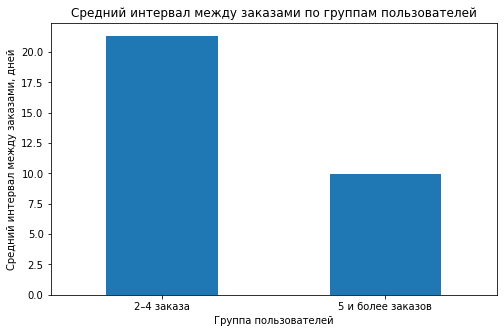

In [118]:
interval_by_orders_group.plot(
    x='orders_group_interval',
    y='avg_days_between_orders',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Средний интервал между заказами по группам пользователей')
plt.xlabel('Группа пользователей')
plt.ylabel('Средний интервал между заказами, дней')
plt.xticks(rotation=0)
plt.show()

In [122]:
repeat_users['interval_group'] = '0–7 дней'

repeat_users.loc[
    repeat_users['avg_days_between_orders'] > 7,
    'interval_group'
] = '8–14 дней'

repeat_users.loc[
    repeat_users['avg_days_between_orders'] > 14,
    'interval_group'
] = '15–30 дней'

repeat_users.loc[
    repeat_users['avg_days_between_orders'] > 30,
    'interval_group'
] = 'более 30 дней'

In [123]:
interval_return = (
    repeat_users
    .groupby('interval_group')
    .agg(
        users=('user_id', 'nunique'),
        users_five_plus=('is_five', 'sum'),
        five_plus_rate=('is_five', 'mean'),
        avg_orders=('total_orders', 'mean')
    )
    .reset_index()
)

interval_order = ['0–7 дней', '8–14 дней', '15–30 дней', 'более 30 дней']

interval_return['interval_group'] = pd.Categorical(
    interval_return['interval_group'],
    categories=interval_order,
    ordered=True
)

interval_return = interval_return.sort_values('interval_group')
interval_return

,interval_group,users,users_five_plus,five_plus_rate,avg_orders
0,0–7 дней,6125,2719,0.443918,14.912327
2,8–14 дней,2484,1875,0.754831,8.897343
1,15–30 дней,2548,1404,0.551020,5.068289
3,более 30 дней,2152,134,0.062268,2.777416


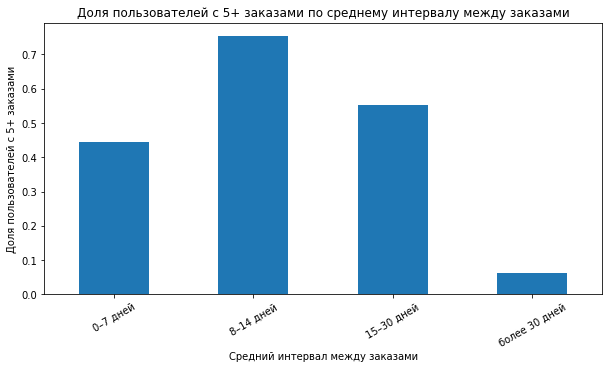

In [124]:
interval_return.plot(
    x='interval_group',
    y='five_plus_rate',
    kind='bar',
    figsize=(10, 5),
    legend=False
)

plt.title('Доля пользователей с 5+ заказами по среднему интервалу между заказами')
plt.xlabel('Средний интервал между заказами')
plt.ylabel('Доля пользователей с 5+ заказами')
plt.xticks(rotation=30)
plt.show()

### Промежуточный вывод

Средний интервал между заказами заметно различается у пользователей с разным уровнем активности. У пользователей, совершивших 2–4 заказа, средний интервал между покупками составляет около 21.3 дня, а у пользователей с 5 и более заказами — около 9.8 дня. Это показывает, что более лояльные пользователи возвращаются за покупками быстрее.

Дополнительная группировка по среднему интервалу между заказами подтвердила эту связь. Самая высокая доля пользователей с 5 и более заказами наблюдается в группе с интервалом 8–14 дней — около 75.5%. В группе с интервалом 15–30 дней показатель ниже — около 55.1%, а при интервале более 30 дней доля пользователей с 5 и более заказами резко падает до 6.2%.

Группа с интервалом 0–7 дней показывает долю пользователей с 5 и более заказами около 44.4%. Несмотря на короткий интервал, этот сегмент уступает группе 8–14 дней, поэтому слишком частые покупки не обязательно связаны с максимальной долгосрочной активностью.

В целом средний интервал между заказами связан с удержанием: пользователи с более коротким и регулярным интервалом покупок чаще становятся лояльными. Наиболее перспективным выглядит сегмент с интервалом 8–14 дней.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [127]:
corr_columns = [
    'total_orders',
    'first_device_type',
    'first_region_name',
    'first_service_name',
    'first_event_type_main',
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_between_orders',
    'first_order_weekday'
]

corr_data = user_profile[corr_columns].copy()

In [128]:
phik_matrix = corr_data.phik_matrix()

phik_matrix

interval columns not set, guessing: ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between_orders']


,total_orders,first_device_type,first_region_name,first_service_name,first_event_type_main,avg_revenue_rub,avg_tickets_count,avg_days_between_orders,first_order_weekday
total_orders,1.000000,0.008432,0.124273,0.021844,0.051391,0.220312,0.224315,0.283542,0.060212
first_device_type,0.008432,1.000000,0.179818,0.108212,0.076116,0.066504,0.045877,0.009353,0.083165
first_region_name,0.124273,0.179818,1.000000,0.696543,0.500912,0.358733,0.164703,0.059332,0.150280
first_service_name,0.021844,0.108212,0.696543,1.000000,0.573827,0.379112,0.066159,0.051616,0.061525
first_event_type_main,0.051391,0.076116,0.500912,0.573827,1.000000,0.322269,0.094832,0.043472,0.056902
avg_revenue_rub,0.220312,0.066504,0.358733,0.379112,0.322269,1.000000,0.457289,0.091281,0.010134
avg_tickets_count,0.224315,0.045877,0.164703,0.066159,0.094832,0.457289,1.000000,0.099905,0.004822
avg_days_between_orders,0.283542,0.009353,0.059332,0.051616,0.043472,0.091281,0.099905,1.000000,0.000000
first_order_weekday,0.060212,0.083165,0.150280,0.061525,0.056902,0.010134,0.004822,0.000000,1.000000


In [129]:
total_orders_corr = (
    phik_matrix['total_orders']
    .drop('total_orders')
    .sort_values(ascending=False)
)

total_orders_corr

avg_days_between_orders    0.283542
avg_tickets_count          0.224315
avg_revenue_rub            0.220312
first_region_name          0.124273
first_order_weekday        0.060212
first_event_type_main      0.051391
first_service_name         0.021844
first_device_type          0.008432
Name: total_orders, dtype: float64

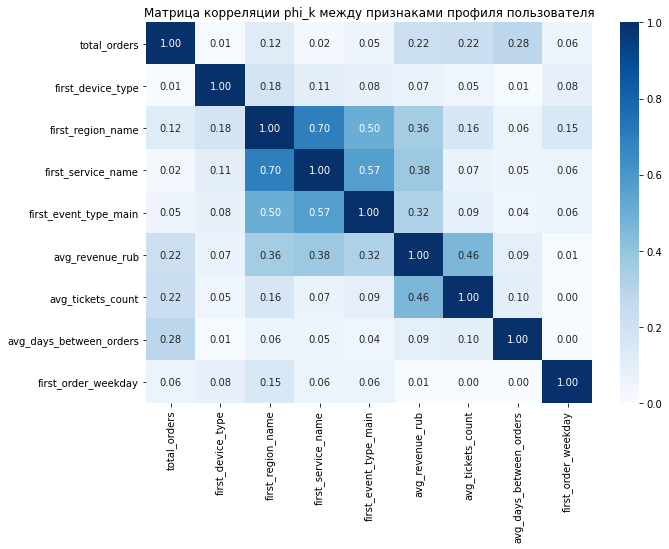

In [130]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    phik_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('Матрица корреляции phi_k между признаками профиля пользователя')
plt.show()

### Промежуточный вывод

Для оценки связи между количеством заказов пользователя и признаками его профиля был рассчитан коэффициент корреляции `phi_k`. Этот коэффициент подходит для текущей задачи, так как позволяет сравнивать как числовые, так и категориальные признаки.

Наиболее заметная связь с количеством заказов наблюдается у среднего интервала между заказами: значение `phi_k` составляет около 0.28. Это согласуется с предыдущим анализом: пользователи, которые делают заказы с меньшим и более регулярным интервалом, чаще совершают больше покупок.

Также умеренная связь есть у среднего количества билетов в заказе и средней выручки с заказа: значения `phi_k` составляют около 0.22. Эти признаки связаны с покупательским поведением пользователя, но связь нельзя считать сильной. Они могут быть полезны для анализа лояльности, однако сами по себе не объясняют количество заказов полностью.

Среди признаков первого заказа наиболее заметна связь с регионом первого мероприятия: `phi_k` около 0.12. Это слабая связь, но она подтверждает, что региональный фактор может влиять на повторные покупки. День недели, тип первого мероприятия, билетный оператор и устройство первого заказа имеют очень слабую связь с количеством заказов.

В целом сильных корреляций с `total_orders` не обнаружено. Наиболее важными признаками выглядят средний интервал между заказами, среднее количество билетов и средняя выручка. Это означает, что количество заказов сильнее связано не с самим фактом первого контакта, а с дальнейшим покупательским поведением пользователя.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

## Общий вывод и рекомендации

В проекте были проанализированы данные о заказах пользователей Яндекс Афиши. В исходную выгрузку вошли данные о пользователях, заказах, устройствах, выручке, количестве билетов, мероприятиях, билетных операторах, городах и регионах. Выручка была приведена к единой валюте — российскому рублю. На этапе предобработки были удалены отрицательные значения выручки и значения `revenue_rub` выше 99-го перцентиля. После фильтрации осталось 288 813 заказов. Также были исключены пользователи с аномально большим количеством заказов: после фильтрации пользовательский профиль содержит 21 685 пользователей.

В выборке 61.4% пользователей совершили 2 и более заказа, а 28.3% — 5 и более заказов. Это говорит о том, что в данных есть значимая доля возвращающихся пользователей, но при этом почти 39% пользователей ограничиваются одной покупкой. Основная задача маркетинга — переводить пользователей из первой покупки в повторную.

Анализ первого заказа показал, что пользователи распределены по сегментам неравномерно. Главные точки входа — концерты, мобильные устройства, Каменевский регион и несколько крупных билетных операторов. При этом высокая численность сегмента не всегда означает более высокую вероятность возврата.

По типу первого мероприятия лучше среднего возвращаются пользователи, которые начали с выставок, театра и концертов. Гипотеза о том, что пользователи после первого заказа на спортивные мероприятия возвращаются чаще, чем после концертов, не подтвердилась: доля возврата у спорта около 55.8%, у концертов — около 61.9%.

Региональный фактор оказался важным. В топ-10 регионах по числу пользователей доля повторных заказов составляет около 62.6%, а в остальных регионах — около 58.2%. Это подтверждает гипотезу о том, что в более активных регионах пользователи чаще возвращаются на платформу.

Средняя выручка с заказа у пользователей с одним заказом и у пользователей с повторными заказами почти одинакова — около 544 руб. Однако распределение отличается: у повторных пользователей выше медианная средняя выручка. Среди пользователей с 5 и более заказами медианная средняя выручка также выше, чем у пользователей с 2–4 заказами. Это говорит о том, что более лояльные пользователи выглядят более стабильным и качественным сегментом.

Среднее количество билетов связано с возвратом не линейно. Самая высокая доля повторных покупок наблюдается у пользователей, которые в среднем покупают от 2 до 3 билетов — около 73.6%. Пользователи с 5 и более билетами в заказе возвращаются значительно реже — около 18.9%. Значит, крупный заказ по количеству билетов не обязательно означает высокую лояльность.

День недели первой покупки не является сильным фактором возврата. Доля повторных заказов по дням недели находится примерно в диапазоне от 59.4% до 63.0%, поэтому этот признак можно использовать только как дополнительный.

Более важным временным фактором оказался интервал между заказами. Пользователи с 5 и более заказами возвращаются быстрее: средний интервал между покупками у них около 9.8 дня, тогда как у пользователей с 2–4 заказами — около 21.3 дня. Самый перспективный сегмент по удержанию — пользователи со средним интервалом между заказами 8–14 дней: среди них доля пользователей с 5 и более заказами составляет около 75.5%.

Корреляционный анализ `phi_k` показал, что сильных связей с количеством заказов нет. Наиболее заметно с `total_orders` связаны средний интервал между заказами, среднее количество билетов и средняя выручка. Среди признаков первого заказа наиболее заметна связь с регионом, но она слабая. Это означает, что количество заказов сильнее связано не с самим первым контактом, а с дальнейшим покупательским поведением пользователя.

### Рекомендации

Маркетингу стоит в первую очередь работать с сегментами, где одновременно есть достаточный объём пользователей и высокая доля возврата: пользователи, начавшие с концертов, театра и выставок, пользователи из активных регионов, а также клиенты со средним количеством билетов от 2 до 3.

Отдельное внимание стоит уделить активным регионам. В них выше доля повторных заказов, поэтому рекламные кампании и персональные предложения там могут давать лучший эффект. Для менее активных регионов лучше тестировать отдельные механики вовлечения, так как вероятность возврата там ниже.

Пользователей, которые сделали первый заказ и не вернулись в течение 2–3 недель, стоит дополнительно стимулировать: например, напоминаниями, подборками мероприятий или персональными предложениями. Анализ показал, что более лояльные пользователи совершают покупки с меньшим интервалом, поэтому важно не терять контакт с клиентом после первого заказа.

Для пользователей со средним количеством билетов от 2 до 3 можно развивать персональные рекомендации и повторные предложения, так как этот сегмент показывает самую высокую долю возврата. Пользователей с очень крупными заказами по количеству билетов не стоит автоматически считать лояльными: они возвращаются реже, поэтому для них нужны отдельные сценарии удержания.

В качестве основных признаков для будущей модели прогнозирования возврата стоит использовать средний интервал между заказами, среднее количество билетов, среднюю выручку, регион первого заказа, тип первого мероприятия и билетного оператора. При этом признаки `is_two` и `is_five` не следует использовать как независимые признаки для прогнозирования, так как они напрямую зависят от количества заказов.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**